# FIT5196 Assessment 1 — Exploratory Data Analysis

**Group:** Group050

**Members:**  
Xingao Zhan — 36354775  
Yu Wang — 34652442  
Keshu Zhang — 36436763  
Qingzhuo Zhao — 26662841

This integrated Task 5–6 notebook reads only the six submitted standardised CSV files from the relative `outputs/` directory. It reproduces eight assessed visualisations, ten evidence-based findings and five future machine-learning questions.

## 0. Configuration and data loading

Load the six standardised CSVs produced by the solution notebook. Keep paths
relative/configurable and use explicit read options where the literal string
`NaN` must remain visible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from IPython.display import display, Markdown

GROUP_ID = "Group050"
OUTPUT_DIR = Path("outputs")

TABLE_FILENAMES = {
    "orders": f"{GROUP_ID}_orders_standardised.csv",
    "order_items": f"{GROUP_ID}_order_items_standardised.csv",
    "customers": f"{GROUP_ID}_customers_standardised.csv",
    "deliveries": f"{GROUP_ID}_deliveries_standardised.csv",
    "products": f"{GROUP_ID}_products_standardised.csv",
    "product_reviews": f"{GROUP_ID}_product_reviews_standardised.csv",
}

TABLE_PATHS = {name: OUTPUT_DIR / filename for name, filename in TABLE_FILENAMES.items()}
missing_files = [str(path) for path in TABLE_PATHS.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "Missing submitted standardised CSV file(s): " + ", ".join(missing_files)
    )

# Okabe–Ito colours: readable in colour and distinguishable for common CVD types.
SERVICE_COLOURS = {"Express": "#0072B2", "Standard": "#E69F00"}
CARRIER_COLOUR = "#009E73"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "legend.frameon": False,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

In [2]:
# keep_default_na=False preserves a literal text value such as "NaN" rather than
# silently converting it to a missing value. Numeric fields are parsed explicitly
# in the figure cells that use them.
tables = {
    name: pd.read_csv(path, encoding="utf-8", keep_default_na=False)
    for name, path in TABLE_PATHS.items()
}

orders = tables["orders"]
order_items = tables["order_items"]
customers = tables["customers"]
deliveries = tables["deliveries"]
products = tables["products"]
product_reviews = tables["product_reviews"]

load_manifest = pd.DataFrame([
    {
        "table": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "source_file": TABLE_PATHS[name].name,
    }
    for name, frame in tables.items()
])

display(Markdown("**Submitted standardised files loaded**"))
display(load_manifest)
print(f"EDA_DATA_READY {len(tables)}/6")

**Submitted standardised files loaded**

,table,rows,columns,source_file
0,orders,5000,23,Group050_orders_standardised.csv
1,order_items,15711,6,Group050_order_items_standardised.csv
2,customers,500,20,Group050_customers_standardised.csv
3,deliveries,5000,20,Group050_deliveries_standardised.csv
4,products,1000,21,Group050_products_standardised.csv
5,product_reviews,7000,21,Group050_product_reviews_standardised.csv


EDA_DATA_READY 6/6


## 1. Context and data-preparation assurance

Briefly define the business context and data scope. Summarise 3-5 material
transformation decisions and 4-6 material validation results by citing stable
`MAP-...` and `VAL-...` IDs. Do not repeat the complete mapping or notebook.


Replace with the concise assurance narrative.


## 2. Assessed EDA visualisations

Submit 6-8 clearly labelled assessed figures. Across the set, cover all six
published categories, at least four tables and at least two valid relational
analyses. For each figure state the question, observation unit, denominator,
tables/join keys, interpretation and material limitation.


### Figure 1: Distribution of completed-order value

**Analytical question:** How are completed order totals distributed, and where does the high-value tail begin?  
**Observation unit:** One canonical completed order.  
**Denominator:** All 5,000 rows in `orders`; monetary values are AUD.  
**Tables used:** `orders`.  
**Join keys:** No join; `order_id` is checked as the primary key.  
**Join multiplication check:** Not applicable; all calculations remain at one row per order.  
**Result:** The distribution is right-skewed. The median is A$2,491.42, the middle 50% spans A$1,449.17–A$3,951.42, and the 90th percentile is A$5,702.77; 500 orders form the upper decile.  
**Material limitation:** `order_total` combines merchandise, tax, delivery and discounts. The figure cannot identify which component or product mix produces the tail, and completed orders do not represent cancelled or abandoned demand.

**Figure 1 grain checks and summary**

,check,observed,expected,status
0,Rows at order grain,5000,5000,PASS
1,Non-empty order_id,5000,5000,PASS
2,Unique order_id,5000,5000,PASS
3,Completed orders,5000,5000,PASS


,orders,median_AUD,Q1_AUD,Q3_AUD,p90_AUD,orders_at_or_above_p90,maximum_AUD
0,5000,2491.42,1449.17,3951.42,5702.77,500,15217.95


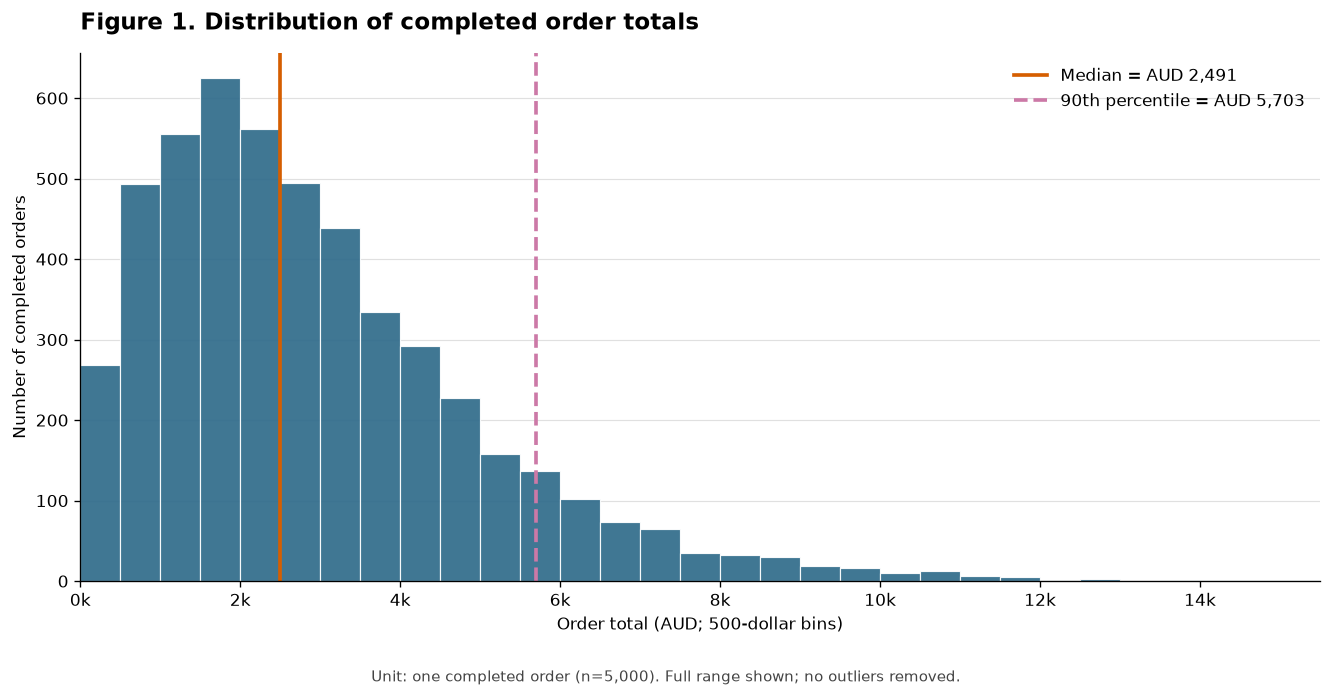

FIGURE1_COMPLETE rows=5000 median=2491.42 p90=5702.77


In [3]:
required_fig1_columns = {"order_id", "order_status", "order_total"}
missing_fig1_columns = required_fig1_columns.difference(orders.columns)
if missing_fig1_columns:
    raise KeyError(f"orders is missing Figure 1 field(s): {sorted(missing_fig1_columns)}")

fig1_orders = orders[["order_id", "order_status", "order_total"]].copy()
fig1_orders["order_total"] = pd.to_numeric(fig1_orders["order_total"], errors="raise")
non_empty_order_ids = fig1_orders["order_id"].astype(str).str.strip().ne("").sum()
unique_order_ids = fig1_orders["order_id"].nunique(dropna=False)
completed_orders = fig1_orders["order_status"].eq("Completed").sum()

fig1_checks = pd.DataFrame([
    {"check": "Rows at order grain", "observed": len(fig1_orders), "expected": len(orders)},
    {"check": "Non-empty order_id", "observed": non_empty_order_ids, "expected": len(fig1_orders)},
    {"check": "Unique order_id", "observed": unique_order_ids, "expected": len(fig1_orders)},
    {"check": "Completed orders", "observed": completed_orders, "expected": len(fig1_orders)},
])
fig1_checks["status"] = np.where(fig1_checks["observed"] == fig1_checks["expected"], "PASS", "FAIL")
if not (fig1_checks["status"] == "PASS").all():
    raise AssertionError("Figure 1 order-grain validation failed")

order_total = fig1_orders["order_total"]
median_total = order_total.median()
q1_total = order_total.quantile(0.25)
q3_total = order_total.quantile(0.75)
p90_total = order_total.quantile(0.90)
high_value_orders = int(order_total.ge(p90_total).sum())

figure1_summary = pd.DataFrame([{
    "orders": len(order_total),
    "median_AUD": median_total,
    "Q1_AUD": q1_total,
    "Q3_AUD": q3_total,
    "p90_AUD": p90_total,
    "orders_at_or_above_p90": high_value_orders,
    "maximum_AUD": order_total.max(),
}]).round(2)

display(Markdown("**Figure 1 grain checks and summary**"))
display(fig1_checks)
display(figure1_summary)

fig, ax = plt.subplots(figsize=(11.2, 5.8))
upper_edge = int(np.ceil(order_total.max() / 500) * 500) + 500
bins = np.arange(0, upper_edge + 1, 500)
ax.hist(order_total, bins=bins, color="#2F6B8A", edgecolor="white", linewidth=0.7, alpha=0.92)
ax.axvline(median_total, color="#D55E00", linewidth=2.2, label=f"Median = AUD {median_total:,.0f}")
ax.axvline(p90_total, color="#CC79A7", linewidth=2.2, linestyle="--", label=f"90th percentile = AUD {p90_total:,.0f}")
ax.set_title("Figure 1. Distribution of completed order totals", loc="left", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Order total (AUD; 500-dollar bins)")
ax.set_ylabel("Number of completed orders")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value/1000:.0f}k"))
ax.set_xlim(0, upper_edge - 500)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
ax.legend(loc="upper right", frameon=False)
fig.text(0.5, 0.012, "Unit: one completed order (n=5,000). Full range shown; no outliers removed.", ha="center", fontsize=9, color="#444444")
fig.tight_layout(rect=(0, 0.055, 1, 1))
plt.show()
print(f"FIGURE1_COMPLETE rows={len(fig1_orders)} median={median_total:.2f} p90={p90_total:.2f}")

### Figure 2: Basket units and completed-order value

**Analytical question:** How does completed order total differ as the number of purchased units increases?  
**Observation unit:** One canonical completed order after aggregating its order-item rows.  
**Denominator:** All 5,000 orders with matched items; `total_units` is the sum of `quantity` per `order_id`.  
**Tables used:** `orders` and `order_items`.  
**Join keys:** Aggregate `order_items` by `order_id`, then join to `orders.order_id`.  
**Join multiplication check:** `validate="one_to_one"` retains 5,000 rows and 5,000 unique orders; all 15,711 item rows contribute only through their order-level aggregate.  
**Result:** Median order total rises from A$551.08 for one-unit orders (n=324) to A$5,245.05 for 8+ units (n=143); Spearman ρ=0.634 indicates a moderately strong positive association.  
**Material limitation:** Part of the association is mechanical because additional units add value. Product category, unit price, discount, tax and delivery charges are not controlled, while 8+ combines several sparse basket sizes.

**Figure 2 join check and group denominators**

,check,observed,expected,status
0,orders rows before join,5000,5000,PASS
1,order_items rows aggregated,15711,15711,PASS
2,order-level basket rows,5000,5000,PASS
3,rows after one-to-one join,5000,5000,PASS
4,unmatched keys,0,0,PASS
5,subtotal/order_price mismatches,0,0,PASS


,orders,median_AUD,Q1_AUD,Q3_AUD
unit_group,,,,
1,324,551.08,283.39,1022.62
2,644,1281.20,769.13,1951.54
3,1082,1876.55,1207.88,2826.41
4,1114,2706.27,1804.66,3748.48
5,862,3350.99,2321.93,4707.67
6,543,3724.96,2732.98,5308.02
7,288,4728.74,3368.86,6206.25
8+,143,5245.05,3916.89,7702.93


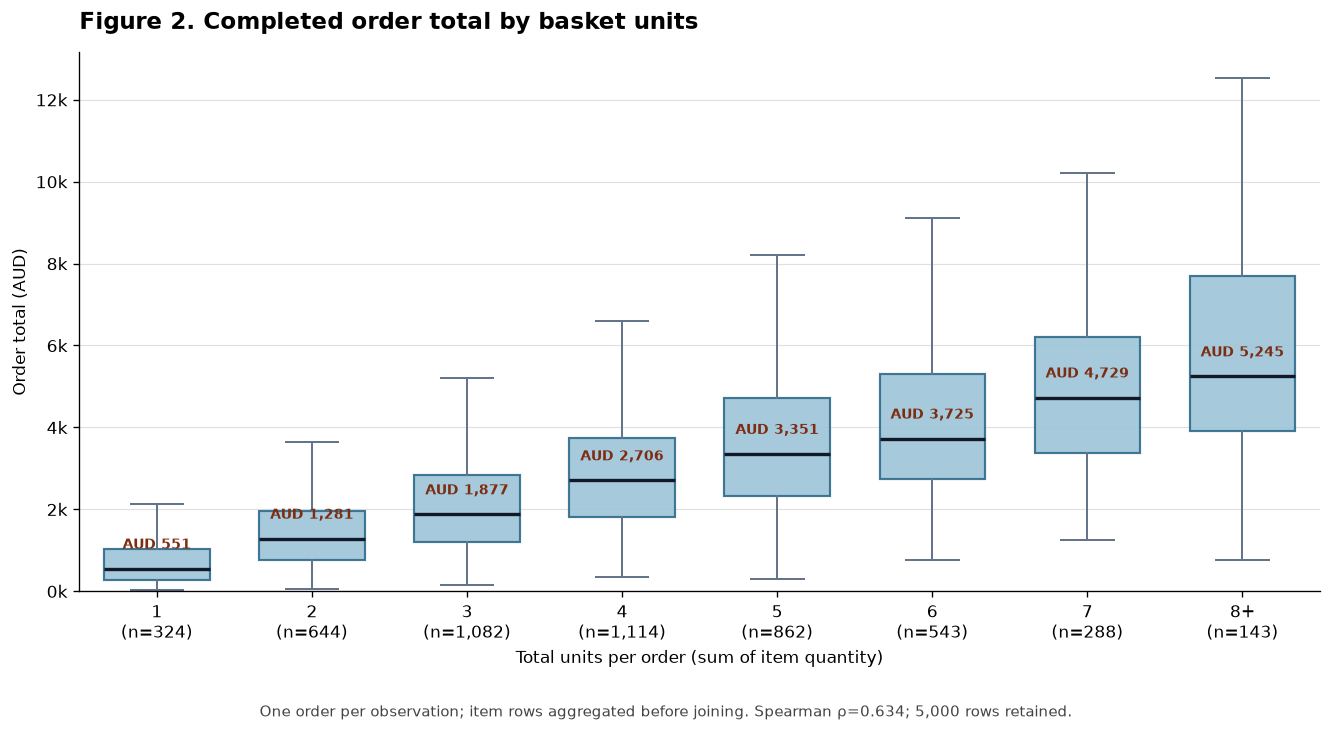

FIGURE2_COMPLETE orders=5000 item_rows=15711 spearman=0.634


In [4]:
required_fig2_item_columns = {"order_item_id", "order_id", "quantity", "line_revenue"}
missing_fig2_item_columns = required_fig2_item_columns.difference(order_items.columns)
if missing_fig2_item_columns:
    raise KeyError(f"order_items is missing Figure 2 field(s): {sorted(missing_fig2_item_columns)}")

fig2_items = order_items[["order_item_id", "order_id", "quantity", "line_revenue"]].copy()
fig2_items["quantity"] = pd.to_numeric(fig2_items["quantity"], errors="raise")
fig2_items["line_revenue"] = pd.to_numeric(fig2_items["line_revenue"], errors="raise")
if not fig2_items["order_item_id"].is_unique:
    raise AssertionError("order_items.order_item_id must be unique")

order_baskets = (
    fig2_items.groupby("order_id", as_index=False)
    .agg(total_units=("quantity", "sum"), line_count=("order_item_id", "size"), item_subtotal=("line_revenue", "sum"))
)
fig2_order_side = orders[["order_id", "order_total", "order_price"]].copy()
fig2_order_side["order_total"] = pd.to_numeric(fig2_order_side["order_total"], errors="raise")
fig2_order_side["order_price"] = pd.to_numeric(fig2_order_side["order_price"], errors="raise")
if not fig2_order_side["order_id"].is_unique:
    raise AssertionError("orders.order_id must be unique")

item_only_keys = set(order_baskets["order_id"]) - set(fig2_order_side["order_id"])
order_only_keys = set(fig2_order_side["order_id"]) - set(order_baskets["order_id"])
order_analysis = fig2_order_side.merge(order_baskets, on="order_id", how="inner", validate="one_to_one")
subtotal_mismatches = int((order_analysis["item_subtotal"] - order_analysis["order_price"]).abs().gt(0.01).sum())

fig2_join_check = pd.DataFrame([
    {"check": "orders rows before join", "observed": len(fig2_order_side), "expected": len(orders)},
    {"check": "order_items rows aggregated", "observed": len(fig2_items), "expected": len(order_items)},
    {"check": "order-level basket rows", "observed": len(order_baskets), "expected": fig2_order_side["order_id"].nunique()},
    {"check": "rows after one-to-one join", "observed": len(order_analysis), "expected": len(fig2_order_side)},
    {"check": "unmatched keys", "observed": len(item_only_keys) + len(order_only_keys), "expected": 0},
    {"check": "subtotal/order_price mismatches", "observed": subtotal_mismatches, "expected": 0},
])
fig2_join_check["status"] = np.where(fig2_join_check["observed"] == fig2_join_check["expected"], "PASS", "FAIL")
if not (fig2_join_check["status"] == "PASS").all():
    raise AssertionError("Figure 2 aggregation/join validation failed")

order_analysis["unit_group"] = order_analysis["total_units"].astype(int).astype(str)
order_analysis.loc[order_analysis["total_units"] >= 8, "unit_group"] = "8+"
group_order = ["1", "2", "3", "4", "5", "6", "7", "8+"]
grouped_totals = [order_analysis.loc[order_analysis["unit_group"].eq(group), "order_total"].to_numpy() for group in group_order]
figure2_summary = (
    order_analysis.groupby("unit_group")["order_total"]
    .agg(orders="size", median_AUD="median", Q1_AUD=lambda values: values.quantile(0.25), Q3_AUD=lambda values: values.quantile(0.75))
    .reindex(group_order)
)
spearman_rho = order_analysis["total_units"].rank(method="average").corr(order_analysis["order_total"].rank(method="average"))

display(Markdown("**Figure 2 join check and group denominators**"))
display(fig2_join_check)
display(figure2_summary.round(2))

fig, ax = plt.subplots(figsize=(11.2, 6.1))
box = ax.boxplot(
    grouped_totals, patch_artist=True, showfliers=False, widths=0.68,
    medianprops={"color": "#111827", "linewidth": 2.0},
    boxprops={"edgecolor": "#2F6B8A", "linewidth": 1.3},
    whiskerprops={"color": "#64748B", "linewidth": 1.2},
    capprops={"color": "#64748B", "linewidth": 1.2},
)
for patch in box["boxes"]:
    patch.set_facecolor("#9CC5D8")
    patch.set_alpha(0.9)
counts = figure2_summary["orders"].astype(int)
medians = figure2_summary["median_AUD"]
ax.set_xticks(range(1, len(group_order) + 1), [f"{group}\n(n={counts.loc[group]:,})" for group in group_order])
for x_position, group in enumerate(group_order, start=1):
    ax.annotate(f"AUD {medians.loc[group]:,.0f}", (x_position, medians.loc[group]), xytext=(0, 10), textcoords="offset points", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#7C2D12")
ax.set_title("Figure 2. Completed order total by basket units", loc="left", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Total units per order (sum of item quantity)")
ax.set_ylabel("Order total (AUD)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value/1000:.0f}k"))
ax.set_ylim(bottom=0)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
fig.text(0.5, 0.012, f"One order per observation; item rows aggregated before joining. Spearman ρ={spearman_rho:.3f}; 5,000 rows retained.", ha="center", fontsize=9, color="#444444")
fig.tight_layout(rect=(0, 0.055, 1, 1))
plt.show()
print(f"FIGURE2_COMPLETE orders={len(order_analysis)} item_rows={len(fig2_items)} spearman={spearman_rho:.3f}")

### Figure 3: Order value by customer segment

**Analytical question:** How does canonical order value differ across customer segments?  
**Observation unit:** One canonical order linked to one customer profile.  
**Denominator:** All 5,000 matched orders, each contributing once.  
**Tables used:** `orders` and `customers`.  
**Join keys:** `orders.customer_id = customers.customer_id`.  
**Join multiplication check:** A validated many-to-one join retains 5,000 rows and 5,000 unique `order_id` values, with zero unmatched customers.  
**Result:** Mainstream has the highest median order total (A$2,561.43) and Small Business the lowest (A$2,440.52), a difference of A$120.91 or about 5.0%; the distributions overlap strongly.  
**Material limitation:** Segment membership is descriptive and may proxy product mix, tenure or purchasing frequency. The chart does not establish that segment causes differences in order value.

**Figure 3 many-to-one join check and segment summary**

,check,observed,expected,status
0,orders before join,5000.0,5000.0,PASS
1,rows after many-to-one join,5000.0,5000.0,PASS
2,unique order_id after join,5000.0,5000.0,PASS
3,unmatched customer rows,0.0,0.0,PASS
4,row multiplication factor,1.0,1.0,PASS


,order_count,mean_order_total,median_order_total,q1_order_total,q3_order_total
customer_segment,,,,,
Mainstream,1294,2998.83,2561.43,1475.71,4019.82
Premium,1288,2956.42,2545.14,1455.79,4057.64
Value,1241,2901.32,2486.75,1495.57,3823.28
Small Business,1177,2883.12,2440.52,1383.03,3926.96


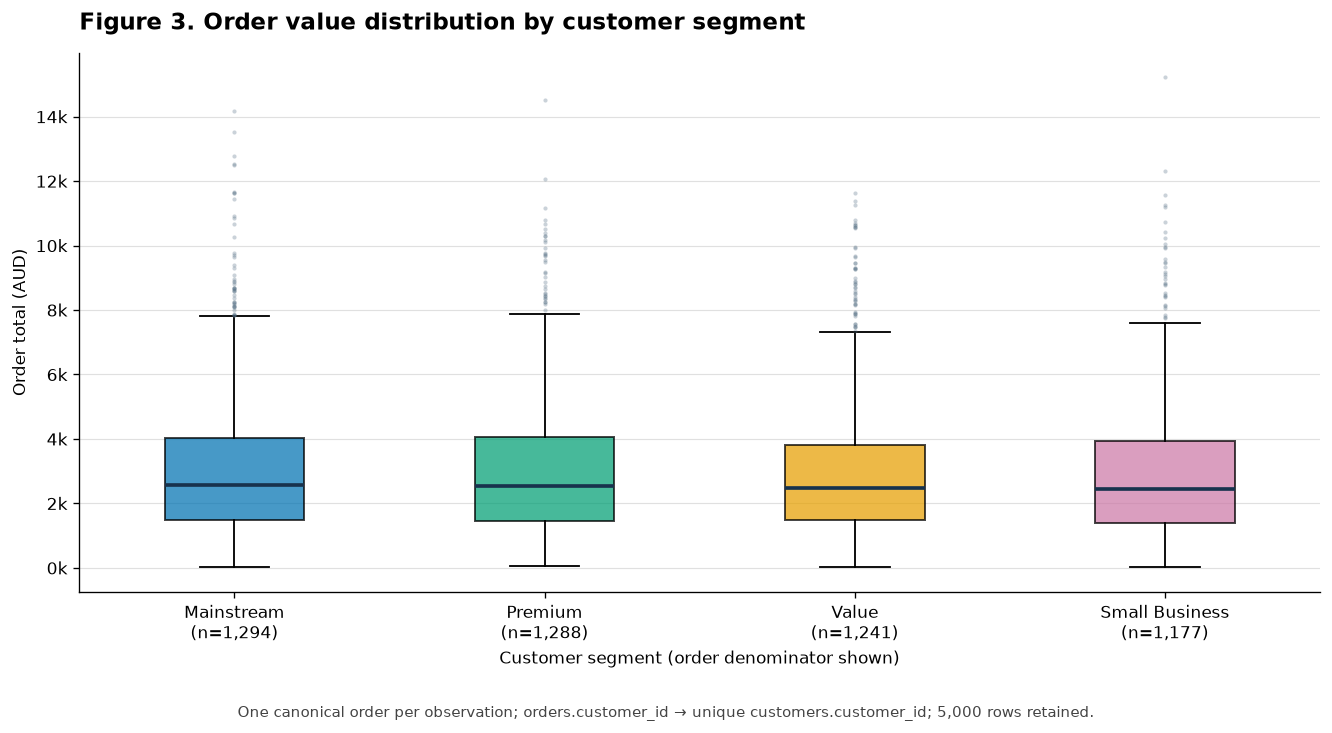

FIGURE3_COMPLETE rows=5000 multiplication=1.000


In [5]:
required_fig3_order_columns = {"order_id", "customer_id", "order_total", "order_timestamp"}
required_fig3_customer_columns = {"customer_id", "customer_segment", "loyalty_tier"}
if required_fig3_order_columns.difference(orders.columns) or required_fig3_customer_columns.difference(customers.columns):
    raise KeyError("orders or customers is missing a Figure 3/4 field")

fig3_orders = orders[list(required_fig3_order_columns)].copy()
fig3_customers = customers[list(required_fig3_customer_columns)].copy()
fig3_orders["order_total"] = pd.to_numeric(fig3_orders["order_total"], errors="raise")
fig3_orders["order_timestamp"] = pd.to_datetime(fig3_orders["order_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")
if not fig3_orders["order_id"].is_unique:
    raise AssertionError("orders.order_id must be unique")
if not fig3_customers["customer_id"].is_unique:
    raise AssertionError("customers.customer_id must be unique")

orders_before_customer_join = len(fig3_orders)
customer_order_eda = fig3_orders.merge(
    fig3_customers[["customer_id", "customer_segment", "loyalty_tier"]],
    on="customer_id", how="left", validate="many_to_one", indicator=True,
)
unmatched_customer_rows = int(customer_order_eda["_merge"].ne("both").sum())
fig3_multiplication_factor = len(customer_order_eda) / customer_order_eda["order_id"].nunique()
fig3_join_audit = pd.DataFrame([
    {"check": "orders before join", "observed": orders_before_customer_join, "expected": len(orders)},
    {"check": "rows after many-to-one join", "observed": len(customer_order_eda), "expected": len(fig3_orders)},
    {"check": "unique order_id after join", "observed": customer_order_eda["order_id"].nunique(), "expected": fig3_orders["order_id"].nunique()},
    {"check": "unmatched customer rows", "observed": unmatched_customer_rows, "expected": 0},
    {"check": "row multiplication factor", "observed": fig3_multiplication_factor, "expected": 1.0},
])
fig3_join_audit["status"] = np.where(np.isclose(pd.to_numeric(fig3_join_audit["observed"]), pd.to_numeric(fig3_join_audit["expected"])), "PASS", "FAIL")
if not (fig3_join_audit["status"] == "PASS").all():
    raise AssertionError("Figure 3 customer join validation failed")
customer_order_eda = customer_order_eda.drop(columns="_merge")

figure3_summary = (
    customer_order_eda.groupby("customer_segment", observed=True)
    .agg(order_count=("order_id", "nunique"), mean_order_total=("order_total", "mean"), median_order_total=("order_total", "median"), q1_order_total=("order_total", lambda values: values.quantile(0.25)), q3_order_total=("order_total", lambda values: values.quantile(0.75)))
    .sort_values("median_order_total", ascending=False)
)
segment_order = figure3_summary.index.tolist()
segment_values = [customer_order_eda.loc[customer_order_eda["customer_segment"].eq(segment), "order_total"].to_numpy() for segment in segment_order]
segment_labels = [f"{segment}\n(n={int(figure3_summary.loc[segment, 'order_count']):,})" for segment in segment_order]
segment_palette = ["#0072B2", "#009E73", "#E69F00", "#CC79A7"]

display(Markdown("**Figure 3 many-to-one join check and segment summary**"))
display(fig3_join_audit)
display(figure3_summary.round(2))

fig, ax = plt.subplots(figsize=(11.2, 6.1))
boxplot = ax.boxplot(
    segment_values, tick_labels=segment_labels, patch_artist=True, showfliers=True,
    medianprops={"color": "#17324D", "linewidth": 2.2},
    boxprops={"linewidth": 1.2}, whiskerprops={"linewidth": 1.1}, capprops={"linewidth": 1.1},
    flierprops={"marker": "o", "markersize": 2.5, "markerfacecolor": "#526D82", "markeredgecolor": "none", "alpha": 0.30},
)
for patch, colour in zip(boxplot["boxes"], segment_palette):
    patch.set_facecolor(colour)
    patch.set_alpha(0.72)
ax.set_title("Figure 3. Order value distribution by customer segment", loc="left", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Customer segment (order denominator shown)")
ax.set_ylabel("Order total (AUD)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value/1000:.0f}k"))
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
fig.text(0.5, 0.012, "One canonical order per observation; orders.customer_id → unique customers.customer_id; 5,000 rows retained.", ha="center", fontsize=9, color="#444444")
fig.tight_layout(rect=(0, 0.055, 1, 1))
plt.show()
print(f"FIGURE3_COMPLETE rows={len(customer_order_eda)} multiplication={fig3_multiplication_factor:.3f}")

### Figure 4: Monthly revenue pattern by customer segment

**Analytical question:** How did canonical order revenue change over time, and did the pattern differ by customer segment?  
**Observation unit:** One customer-segment/month revenue aggregate derived from canonical orders.  
**Denominator:** All 5,000 orders, each allocated once to its order month and customer segment; revenue is not normalised by customer count.  
**Tables used:** `orders` and `customers`.  
**Join keys:** `orders.customer_id = customers.customer_id`, using the validated Figure 3 join.  
**Join multiplication check:** The 48 segment/month aggregates reconcile to all 5,000 orders and the original total order revenue.  
**Result:** Segment peaks are not synchronised: Mainstream peaks in October, Premium in July, Small Business in April and Value in November.  
**Material limitation:** Only one year is observed, so recurring seasonality cannot be established. Revenue totals also combine segment size, order frequency and order value.

**Figure 4 aggregation reconciliation and segment peaks**

,check,observed,expected,status
0,orders represented in monthly groups,5000.0,5000.0,PASS
1,revenue difference after aggregation,-0.0,0.0,PASS
2,segment/month observations,48.0,48.0,PASS


,customer_segment,peak_month,monthly_revenue,order_count
0,Mainstream,October 2018,381761.91,120
1,Premium,July 2018,388351.87,132
2,Small Business,April 2018,331844.89,107
3,Value,November 2018,361477.66,115


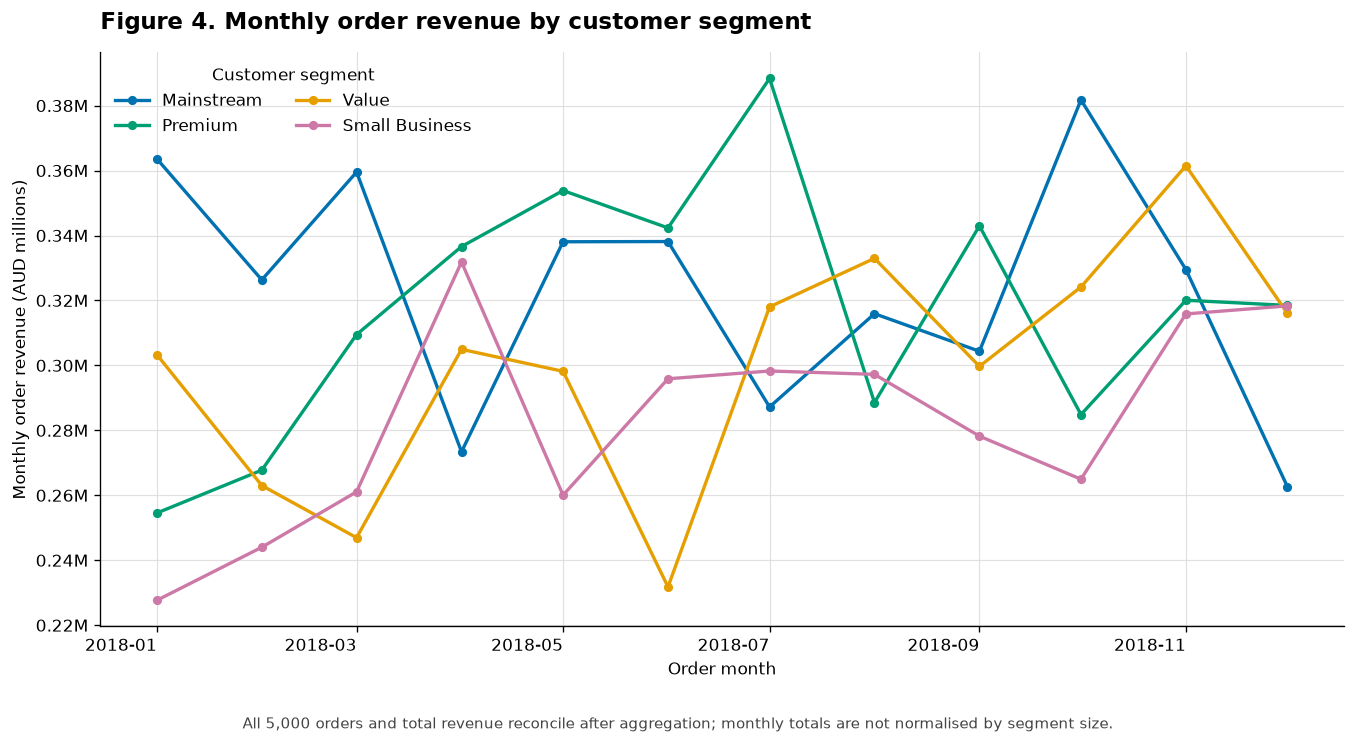

FIGURE4_COMPLETE orders=5000 groups=48


In [6]:
customer_order_eda["order_month"] = customer_order_eda["order_timestamp"].dt.to_period("M").dt.to_timestamp()
figure4_monthly = (
    customer_order_eda.groupby(["order_month", "customer_segment"], as_index=False, observed=True)
    .agg(monthly_revenue=("order_total", "sum"), order_count=("order_id", "nunique"))
    .sort_values(["order_month", "customer_segment"])
)
figure4_order_count_check = int(figure4_monthly["order_count"].sum())
figure4_revenue_check = float(figure4_monthly["monthly_revenue"].sum())
figure4_reconciliation = pd.DataFrame([
    {"check": "orders represented in monthly groups", "observed": figure4_order_count_check, "expected": len(customer_order_eda)},
    {"check": "revenue difference after aggregation", "observed": round(figure4_revenue_check - customer_order_eda["order_total"].sum(), 6), "expected": 0.0},
    {"check": "segment/month observations", "observed": len(figure4_monthly), "expected": customer_order_eda[["order_month", "customer_segment"]].drop_duplicates().shape[0]},
])
figure4_reconciliation["status"] = np.where(np.isclose(pd.to_numeric(figure4_reconciliation["observed"]), pd.to_numeric(figure4_reconciliation["expected"])), "PASS", "FAIL")
if not (figure4_reconciliation["status"] == "PASS").all():
    raise AssertionError("Figure 4 aggregation reconciliation failed")

peak_rows = (
    figure4_monthly.loc[figure4_monthly.groupby("customer_segment")["monthly_revenue"].idxmax()]
    .sort_values("customer_segment").reset_index(drop=True)
)
peak_summary = peak_rows[["customer_segment", "order_month", "monthly_revenue", "order_count"]].copy()
peak_summary["peak_month"] = peak_summary["order_month"].dt.strftime("%B %Y")
peak_summary = peak_summary[["customer_segment", "peak_month", "monthly_revenue", "order_count"]]

display(Markdown("**Figure 4 aggregation reconciliation and segment peaks**"))
display(figure4_reconciliation)
display(peak_summary.round({"monthly_revenue": 2}))

fig, ax = plt.subplots(figsize=(11.4, 6.2))
for colour, segment in zip(segment_palette, segment_order):
    segment_monthly = figure4_monthly.loc[figure4_monthly["customer_segment"].eq(segment)]
    ax.plot(segment_monthly["order_month"], segment_monthly["monthly_revenue"] / 1_000_000, label=segment, color=colour, marker="o", linewidth=2.0, markersize=4.5)
ax.set_title("Figure 4. Monthly order revenue by customer segment", loc="left", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Order month")
ax.set_ylabel("Monthly order revenue (AUD millions)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}M"))
ax.grid(color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
ax.legend(title="Customer segment", frameon=False, ncol=2)
fig.autofmt_xdate(rotation=0)
fig.text(0.5, 0.012, "All 5,000 orders and total revenue reconcile after aggregation; monthly totals are not normalised by segment size.", ha="center", fontsize=9, color="#444444")
fig.tight_layout(rect=(0, 0.055, 1, 1))
plt.show()
print(f"FIGURE4_COMPLETE orders={figure4_order_count_check} groups={len(figure4_monthly)}")

### Figure 5: Late-delivery risk by service level and carrier

**Analytical question:** Where is late-delivery risk concentrated across service levels and carriers?  
**Observation unit:** One canonical delivery.  
**Denominator:** All deliveries within each displayed service-level or carrier group; late means `delay_days > 0`.  
**Tables used:** `deliveries`.  
**Join keys:** No join; `delivery_id` is checked as the primary key.  
**Join multiplication check:** Not applicable; all 5,000 delivery rows contribute exactly once to each separate comparison.  
**Result:** Standard and Express have similar late rates—3.95% (164/4,156) and 3.79% (32/844). StarTrack is highest at 4.51% (57/1,263) and DHL lowest at 3.57% (45/1,262).  
**Material limitation:** These are unadjusted descriptive rates. Route distance, warehouse, service mix and other factors may differ between groups; 196 total late deliveries make small differences sensitive to sampling variation.

**Figure 5 grain and metric checks**

,check,observed,expected,status
0,Rows at delivery grain,5000,5000,PASS
1,Non-empty delivery_id,5000,5000,PASS
2,Unique delivery_id,5000,5000,PASS
3,delay_days / on_time_in_full agreement,5000,5000,PASS


**Figure 5 denominators and late-delivery rates**

,comparison,group,deliveries,late_deliveries,on_time_deliveries,late_rate_pct
0,Service level,Express,844,32,812,3.79
1,Service level,Standard,4156,164,3992,3.95
2,Carrier,DHL,1262,45,1217,3.57
3,Carrier,Direct Freight,1257,45,1212,3.58
4,Carrier,AusPost,1218,49,1169,4.02
5,Carrier,StarTrack,1263,57,1206,4.51


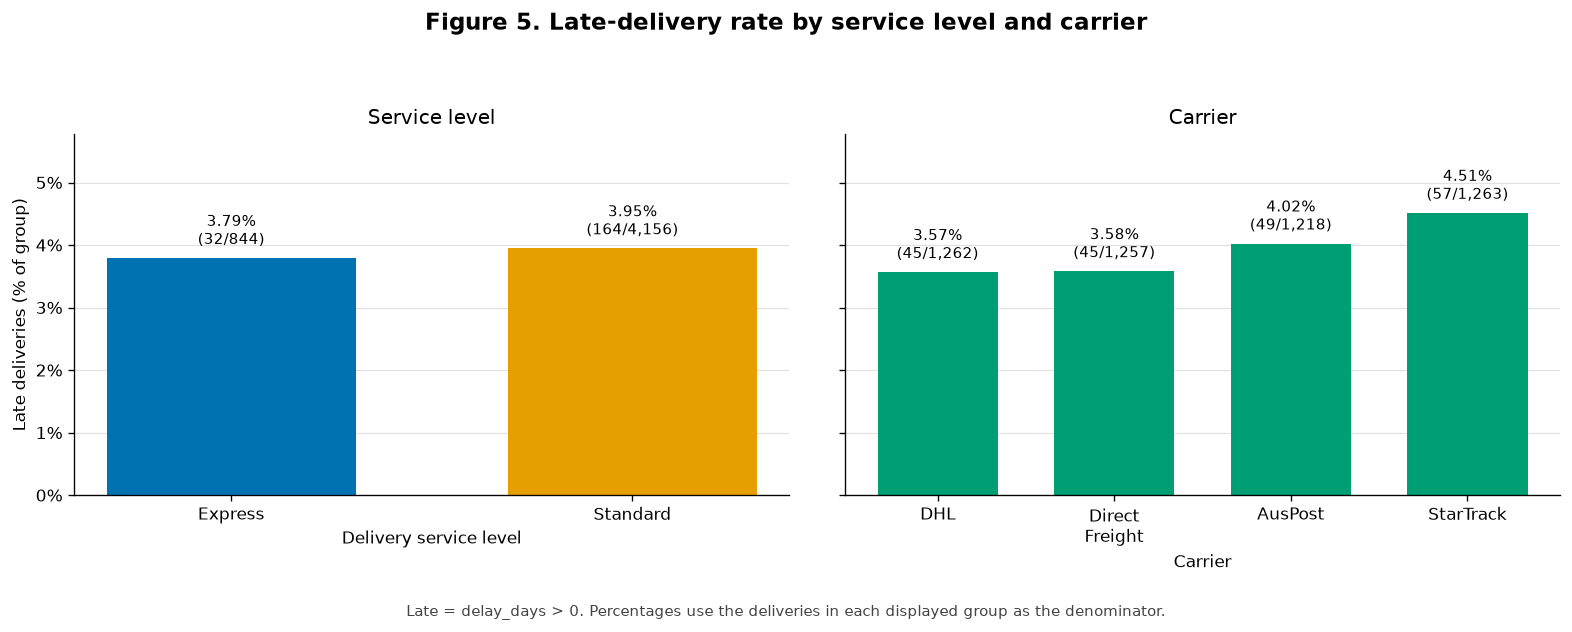

**Figure 5 reproducible result.** Overall, **196/5,000 (3.92%)** deliveries were late. The service-level range is Express 3.79% to Standard 3.95%; the carrier range is DHL 3.57% to StarTrack 4.51%. These descriptive gaps are small and should not be read as causal performance effects.

FIGURE5_COMPLETE rows=5000 late=196 rate_pct=3.92


In [7]:
# Task 5, Figure 5 (Xingao): one row per canonical delivery.
# Read the submitted CSV only; analysis helpers stay in this local copy.
required_delivery_columns = {
    "delivery_id", "order_id", "carrier", "service_level",
    "delay_days", "on_time_in_full"
}
missing_columns = required_delivery_columns.difference(deliveries.columns)
if missing_columns:
    raise KeyError(f"deliveries is missing required column(s): {sorted(missing_columns)}")

fig5_data = deliveries[list(required_delivery_columns)].copy()
fig5_data["delay_days"] = pd.to_numeric(fig5_data["delay_days"], errors="raise")
# The late label follows the published delay field, not a guessed transit-time threshold.
fig5_data["is_late"] = fig5_data["delay_days"] > 0

# Explicit parsing avoids treating the non-empty string "False" as True.
otif_map = {"true": True, "false": False, "1": True, "0": False}
fig5_data["otif_bool"] = (
    fig5_data["on_time_in_full"].astype(str).str.strip().str.lower().map(otif_map)
)
if fig5_data["otif_bool"].isna().any():
    bad_values = sorted(fig5_data.loc[fig5_data["otif_bool"].isna(), "on_time_in_full"].astype(str).unique())
    raise ValueError(f"Unexpected on_time_in_full value(s): {bad_values}")

# Check grain and metric agreement before counting; duplicates would inflate rates.
non_empty_delivery_ids = fig5_data["delivery_id"].astype(str).str.strip().ne("").sum()
unique_delivery_ids = fig5_data["delivery_id"].nunique(dropna=False)
otif_consistent = (fig5_data["is_late"] == ~fig5_data["otif_bool"]).sum()

fig5_checks = pd.DataFrame([
    {"check": "Rows at delivery grain", "observed": len(fig5_data), "expected": len(deliveries)},
    {"check": "Non-empty delivery_id", "observed": non_empty_delivery_ids, "expected": len(fig5_data)},
    {"check": "Unique delivery_id", "observed": unique_delivery_ids, "expected": len(fig5_data)},
    {"check": "delay_days / on_time_in_full agreement", "observed": otif_consistent, "expected": len(fig5_data)},
])
fig5_checks["status"] = np.where(
    fig5_checks["observed"] == fig5_checks["expected"], "PASS", "FAIL"
)
if not (fig5_checks["status"] == "PASS").all():
    raise AssertionError("Figure 5 delivery-grain validation failed")


def late_rate_summary(frame, group_column):
    # The denominator is all deliveries in THIS group, including on-time rows.
    # Sum of the Boolean late flag counts late events at the same grain.
    result = (
        frame.groupby(group_column, dropna=False)
        .agg(
            deliveries=("delivery_id", "size"),
            late_deliveries=("is_late", "sum"),
        )
        .reset_index()
        .rename(columns={group_column: "group"})
    )
    result["late_deliveries"] = result["late_deliveries"].astype(int)
    result["on_time_deliveries"] = result["deliveries"] - result["late_deliveries"]
    result["late_rate_pct"] = 100 * result["late_deliveries"] / result["deliveries"]
    return result


service_summary = late_rate_summary(fig5_data, "service_level")
service_order = [x for x in ["Express", "Standard"] if x in set(service_summary["group"])]
service_order += sorted(set(service_summary["group"]) - set(service_order))
service_summary["group"] = pd.Categorical(
    service_summary["group"], categories=service_order, ordered=True
)
service_summary = service_summary.sort_values("group").reset_index(drop=True)

carrier_summary = late_rate_summary(fig5_data, "carrier").sort_values(
    ["late_rate_pct", "group"]
).reset_index(drop=True)

# Service and carrier are two separate views of the same deliveries.
# Do not sum denominators across the two comparison blocks.
fig5_evidence = pd.concat([
    service_summary.assign(comparison="Service level"),
    carrier_summary.assign(comparison="Carrier"),
], ignore_index=True)
fig5_evidence = fig5_evidence[
    ["comparison", "group", "deliveries", "late_deliveries", "on_time_deliveries", "late_rate_pct"]
]
fig5_evidence["late_rate_pct"] = fig5_evidence["late_rate_pct"].round(2)

display(Markdown("**Figure 5 grain and metric checks**"))
display(fig5_checks)
display(Markdown("**Figure 5 denominators and late-delivery rates**"))
display(fig5_evidence)

# Use a shared, zero-based percentage axis so the panels remain comparable.
# Direct labels include late-count/group-count to make small samples visible.
shared_max = max(service_summary["late_rate_pct"].max(), carrier_summary["late_rate_pct"].max())
y_max = max(5.5, shared_max * 1.28)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), sharey=True)

service_colours = [SERVICE_COLOURS.get(str(group), "#56B4E9") for group in service_summary["group"]]
service_bars = axes[0].bar(
    service_summary["group"].astype(str),
    service_summary["late_rate_pct"],
    color=service_colours,
    width=0.62,
)
axes[0].set_title("Service level")
axes[0].set_ylabel("Late deliveries (% of group)")
axes[0].set_xlabel("Delivery service level")

carrier_labels = [str(x).replace("Direct Freight", "Direct\nFreight") for x in carrier_summary["group"]]
carrier_bars = axes[1].bar(
    carrier_labels,
    carrier_summary["late_rate_pct"],
    color=CARRIER_COLOUR,
    width=0.68,
)
axes[1].set_title("Carrier")
axes[1].set_xlabel("Carrier")

for ax, bars, summary in [
    (axes[0], service_bars, service_summary),
    (axes[1], carrier_bars, carrier_summary),
]:
    ax.set_ylim(0, y_max)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.8)
    ax.set_axisbelow(True)
    for bar, row in zip(bars, summary.itertuples(index=False)):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.025,
            f"{row.late_rate_pct:.2f}%\n({row.late_deliveries:,}/{row.deliveries:,})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.suptitle(
    "Figure 5. Late-delivery rate by service level and carrier",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
fig.text(
    0.5,
    0.012,
    "Late = delay_days > 0. Percentages use the deliveries in each displayed group as the denominator.",
    ha="center",
    fontsize=9,
    color="#444444",
)
fig.tight_layout(rect=(0, 0.055, 1, 0.92), w_pad=3.0)
plt.show()

# Findings 6-7 use these unrounded group summaries and overall counts.
# These are descriptive comparisons, not adjusted causal carrier effects.
service_high = service_summary.loc[service_summary["late_rate_pct"].idxmax()]
service_low = service_summary.loc[service_summary["late_rate_pct"].idxmin()]
carrier_high = carrier_summary.loc[carrier_summary["late_rate_pct"].idxmax()]
carrier_low = carrier_summary.loc[carrier_summary["late_rate_pct"].idxmin()]
overall_late = int(fig5_data["is_late"].sum())
overall_rate = 100 * overall_late / len(fig5_data)

display(Markdown(
    f"**Figure 5 reproducible result.** Overall, **{overall_late:,}/{len(fig5_data):,} "
    f"({overall_rate:.2f}%)** deliveries were late. The service-level range is "
    f"{service_low['group']} {service_low['late_rate_pct']:.2f}% to "
    f"{service_high['group']} {service_high['late_rate_pct']:.2f}%; the carrier range is "
    f"{carrier_low['group']} {carrier_low['late_rate_pct']:.2f}% to "
    f"{carrier_high['group']} {carrier_high['late_rate_pct']:.2f}%. "
    "These descriptive gaps are small and should not be read as causal performance effects."
))
print(f"FIGURE5_COMPLETE rows={len(fig5_data)} late={overall_late} rate_pct={overall_rate:.2f}")

### Figure 6: Order value, expedited service and late-delivery risk

**Analytical question:** How is late-delivery risk associated with order value and expedited/service-level status?  
**Observation unit:** One matched order–delivery pair.  
**Denominator:** Each order-value quintile × service-level subgroup; every quintile contains 1,000 matched orders.  
**Tables used:** `orders` and `deliveries`.  
**Join keys:** `orders.order_id = deliveries.order_id`.  
**Join multiplication check:** `validate="one_to_one"` matches all 5,000 pairs, leaves zero unmatched keys and produces a row-multiplication factor of 1.000.  
**Result:** Late rates do not rise monotonically with order value. Express ranges from 3.03% in Q3 (6/198) to 5.36% in Q4 (9/168); Standard ranges from 3.16% in Q1 (27/854) to 4.74% in Q3 (38/802).  
**Material limitation:** Value bands are dataset-specific and the analysis does not adjust for distance, carrier, warehouse, season or product mix. Express cells contain only 5–9 late events.

**Figure 6 one-to-one join and semantic checks**

,check,observed,expected,status
0,Orders before join,5000.0,5000.0,PASS
1,Deliveries before join,5000.0,5000.0,PASS
2,Matched rows after join,5000.0,5000.0,PASS
3,Unmatched order keys,0.0,0.0,PASS
4,Unmatched delivery keys,0.0,0.0,PASS
5,Unique matched order_id,5000.0,5000.0,PASS
6,Row multiplication factor,1.0,1.0,PASS


Service/expedited agreement: 5,000/5,000 pairs (True=Express; False=Standard)


**Order-total quintile definitions (each denominator starts at 1,000 matched orders)**

,value_quintile,matched_orders,minimum_order_total_AUD,maximum_order_total_AUD,configured_range_AUD
0,Q1 (lowest),1000,25.04,1216.04,"A$25–A$1,216"
1,Q2,1000,1216.39,2042.90,"A$1,216–A$2,043"
2,Q3,1000,2043.30,3001.94,"A$2,043–A$3,003"
3,Q4,1000,3004.29,4373.31,"A$3,003–A$4,374"
4,Q5 (highest),1000,4378.28,15217.95,"A$4,374–A$15,218"


**Figure 6 subgroup denominators and late-delivery rates**

,value_quintile,service_level,matched_orders,late_deliveries,late_rate_pct
0,Q1 (lowest),Express,146,5,3.42
1,Q1 (lowest),Standard,854,27,3.16
2,Q2,Express,154,5,3.25
3,Q2,Standard,846,32,3.78
4,Q3,Express,198,6,3.03
5,Q3,Standard,802,38,4.74
6,Q4,Express,168,9,5.36
7,Q4,Standard,832,34,4.09
8,Q5 (highest),Express,178,7,3.93
9,Q5 (highest),Standard,822,33,4.01


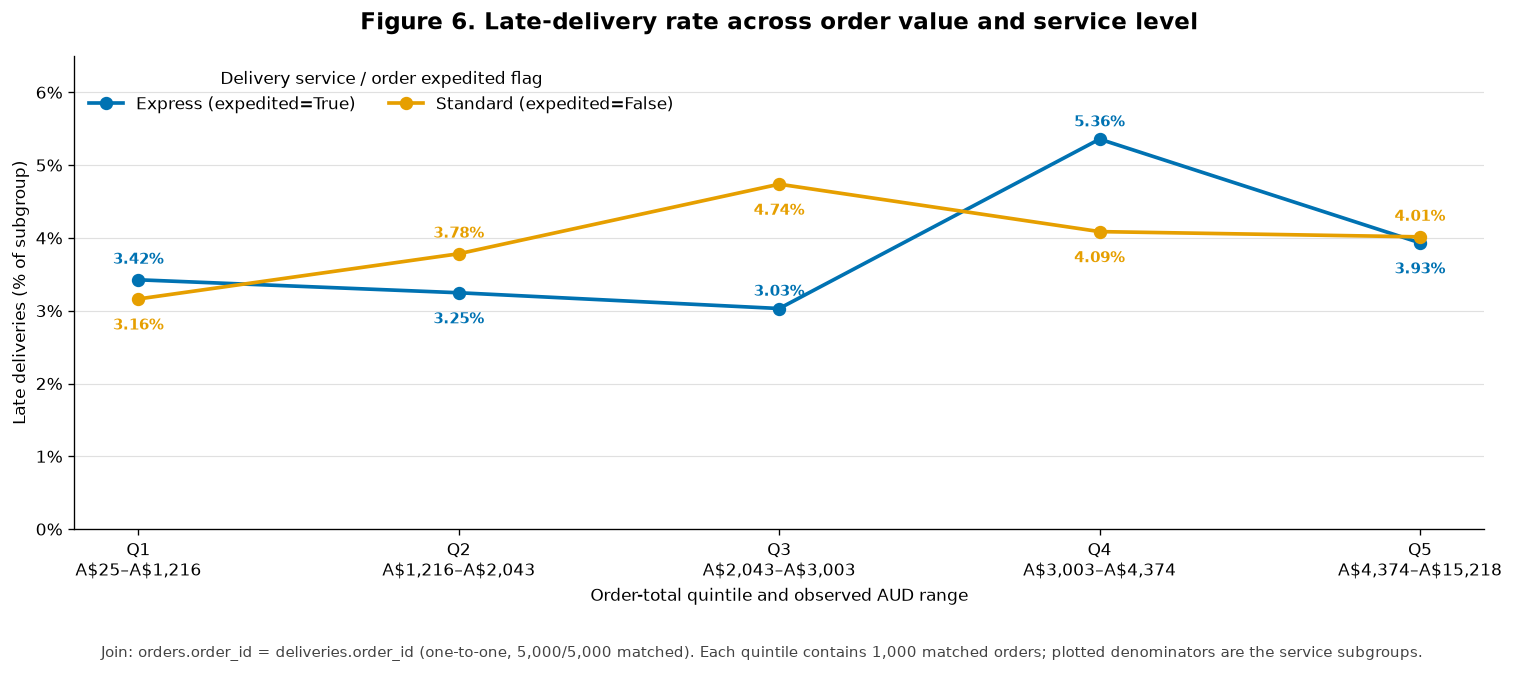

**Figure 6 reproducible result.** The highest displayed subgroup is **Q4 / Express** at **5.36%** (9/168); the lowest is **Q3 / Express** at **3.03%** (6/198). Overall Express (3.79%) and Standard (3.95%) are close, and neither series shows a monotonic increase with order value.

FIGURE6_COMPLETE matched=5000 unmatched_orders=0 unmatched_deliveries=0 multiplication=1.000


In [8]:
# Task 5, Figure 6 (Xingao): compare order-value bands at one order-delivery pair.
# Join checks come before plotting, so unmatched or multiplied rows cannot hide.
required_order_columns = {"order_id", "order_total", "currency", "expedited_delivery"}
required_delivery_columns = {
    "order_id", "delivery_id", "service_level", "delay_days", "on_time_in_full"
}
missing_order_columns = required_order_columns.difference(orders.columns)
missing_delivery_columns = required_delivery_columns.difference(deliveries.columns)
if missing_order_columns or missing_delivery_columns:
    raise KeyError(
        f"Missing fields — orders: {sorted(missing_order_columns)}; "
        f"deliveries: {sorted(missing_delivery_columns)}"
    )

order_side = orders[list(required_order_columns)].copy()
delivery_side = deliveries[list(required_delivery_columns)].copy()

# This completed-order dataset requires a one-to-one relationship on order_id.
if not order_side["order_id"].is_unique:
    raise AssertionError("orders.order_id must be unique for the Figure 6 one-to-one join")
if not delivery_side["order_id"].is_unique:
    raise AssertionError("deliveries.order_id must be unique for the Figure 6 one-to-one join")

order_side["order_total"] = pd.to_numeric(order_side["order_total"], errors="raise")
if (order_side["order_total"] < 0).any():
    raise ValueError("order_total must be non-negative")

currencies = set(order_side["currency"].astype(str).str.strip())
if currencies != {"AUD"}:
    raise ValueError(f"Figure 6 requires one common currency; observed: {sorted(currencies)}")

# Parse string booleans explicitly rather than relying on Python string truthiness.
bool_map = {"true": True, "false": False, "1": True, "0": False}
order_side["expedited_bool"] = (
    order_side["expedited_delivery"].astype(str).str.strip().str.lower().map(bool_map)
)
delivery_side["otif_bool"] = (
    delivery_side["on_time_in_full"].astype(str).str.strip().str.lower().map(bool_map)
)
if order_side["expedited_bool"].isna().any() or delivery_side["otif_bool"].isna().any():
    raise ValueError("Unexpected boolean representation in expedited_delivery or on_time_in_full")

delivery_side["delay_days"] = pd.to_numeric(delivery_side["delay_days"], errors="raise")
delivery_side["is_late"] = delivery_side["delay_days"] > 0
if not (delivery_side["is_late"] == ~delivery_side["otif_bool"]).all():
    raise AssertionError("delay_days and on_time_in_full disagree")

# An outer audit join exposes unmatched keys on either side; an inner join
# alone could silently remove them. validate enforces one-to-one cardinality.
joined = order_side.merge(
    delivery_side,
    on="order_id",
    how="outer",
    validate="one_to_one",
    indicator=True,
)
join_counts = joined["_merge"].value_counts()
matched_rows = int(join_counts.get("both", 0))
unmatched_orders = int(join_counts.get("left_only", 0))
unmatched_deliveries = int(join_counts.get("right_only", 0))
matched_unique_orders = joined.loc[joined["_merge"] == "both", "order_id"].nunique()
row_multiplication_factor = matched_rows / matched_unique_orders if matched_unique_orders else np.nan

fig6_join_checks = pd.DataFrame([
    {"check": "Orders before join", "observed": len(order_side), "expected": len(orders)},
    {"check": "Deliveries before join", "observed": len(delivery_side), "expected": len(deliveries)},
    {"check": "Matched rows after join", "observed": matched_rows, "expected": len(order_side)},
    {"check": "Unmatched order keys", "observed": unmatched_orders, "expected": 0},
    {"check": "Unmatched delivery keys", "observed": unmatched_deliveries, "expected": 0},
    {"check": "Unique matched order_id", "observed": matched_unique_orders, "expected": order_side["order_id"].nunique()},
    {"check": "Row multiplication factor", "observed": row_multiplication_factor, "expected": 1.0},
])
fig6_join_checks["status"] = np.where(
    np.isclose(
        pd.to_numeric(fig6_join_checks["observed"]),
        pd.to_numeric(fig6_join_checks["expected"]),
    ),
    "PASS",
    "FAIL",
)
if not (fig6_join_checks["status"] == "PASS").all():
    raise AssertionError("Figure 6 join validation failed")

# Keep matched pairs only after zero-unmatched and multiplication checks pass.
fig6_data = joined.loc[joined["_merge"] == "both"].drop(columns="_merge").copy()
# Verify the dataset-specific Express/expedited relationship before using one legend.
fig6_data["expected_service_level"] = np.where(
    fig6_data["expedited_bool"], "Express", "Standard"
)
service_flag_matches = (
    fig6_data["expected_service_level"] == fig6_data["service_level"]
)
if not service_flag_matches.all():
    raise AssertionError("expedited_delivery and service_level disagree")

# qcut derives roughly equal-count value bands from the current order totals.
# These are value quintiles, not equal-width price intervals or time periods.
quintile_names = ["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
fig6_data["value_quintile"], quintile_edges = pd.qcut(
    fig6_data["order_total"],
    q=5,
    labels=quintile_names,
    retbins=True,
    duplicates="raise",
)
quintile_ranges = [
    f"A${quintile_edges[i]:,.0f}–A${quintile_edges[i + 1]:,.0f}"
    for i in range(len(quintile_edges) - 1)
]
# Escape the dollar sign only for Matplotlib tick labels; keep ordinary A$ text
# in the evidence table above.
quintile_plot_ranges = [label.replace("$", r"\$") for label in quintile_ranges]
quintile_labels = [
    f"Q{i + 1}\n{quintile_plot_ranges[i]}" for i in range(len(quintile_plot_ranges))
]

fig6_band_evidence = (
    fig6_data.groupby("value_quintile", observed=True)
    .agg(
        matched_orders=("order_id", "size"),
        minimum_order_total_AUD=("order_total", "min"),
        maximum_order_total_AUD=("order_total", "max"),
    )
    .reset_index()
)
fig6_band_evidence["configured_range_AUD"] = quintile_ranges
fig6_band_evidence["minimum_order_total_AUD"] = fig6_band_evidence["minimum_order_total_AUD"].round(2)
fig6_band_evidence["maximum_order_total_AUD"] = fig6_band_evidence["maximum_order_total_AUD"].round(2)

# Each rate uses its quintile x service subgroup denominator, not all orders
# in the quintile. Keep raw counts because some cells contain few late events.
fig6_summary = (
    fig6_data.groupby(["value_quintile", "service_level"], observed=True)
    .agg(
        matched_orders=("order_id", "size"),
        late_deliveries=("is_late", "sum"),
    )
    .reset_index()
)
fig6_summary["late_deliveries"] = fig6_summary["late_deliveries"].astype(int)
fig6_summary["late_rate_pct"] = (
    100 * fig6_summary["late_deliveries"] / fig6_summary["matched_orders"]
)
fig6_evidence = fig6_summary.copy()
fig6_evidence["late_rate_pct"] = fig6_evidence["late_rate_pct"].round(2)

service_overall = (
    fig6_data.groupby("service_level")
    .agg(matched_orders=("order_id", "size"), late_deliveries=("is_late", "sum"))
)
service_overall["late_rate_pct"] = (
    100 * service_overall["late_deliveries"] / service_overall["matched_orders"]
)

display(Markdown("**Figure 6 one-to-one join and semantic checks**"))
display(fig6_join_checks)
print(
    f"Service/expedited agreement: {service_flag_matches.sum():,}/{len(fig6_data):,} "
    "pairs (True=Express; False=Standard)"
)
display(Markdown("**Order-total quintile definitions (each denominator starts at 1,000 matched orders)**"))
display(fig6_band_evidence)
display(Markdown("**Figure 6 subgroup denominators and late-delivery rates**"))
display(fig6_evidence)

# Connected points compare ordered VALUE bands; the line is not a time trend.
# Service colours match Figure 5 and percentage labels identify actual rates.
fig, ax = plt.subplots(figsize=(12.8, 5.7))
x = np.arange(len(quintile_names))
service_order = [s for s in ["Express", "Standard"] if s in set(fig6_summary["service_level"])]
service_order += sorted(set(fig6_summary["service_level"]) - set(service_order))

for service in service_order:
    service_data = (
        fig6_summary.loc[fig6_summary["service_level"] == service]
        .set_index("value_quintile")
        .reindex(quintile_names)
        .reset_index()
    )
    colour = SERVICE_COLOURS.get(service, "#56B4E9")
    ax.plot(
        x,
        service_data["late_rate_pct"],
        color=colour,
        marker="o",
        markersize=7,
        linewidth=2.2,
        label=f"{service} ({'expedited=True' if service == 'Express' else 'expedited=False'})",
    )
    for x_pos, row in zip(x, service_data.itertuples(index=False)):
        other_rates = fig6_summary.loc[
            (fig6_summary["value_quintile"] == row.value_quintile)
            & (fig6_summary["service_level"] != service),
            "late_rate_pct",
        ]
        # When two markers are close, place the higher value above and the lower
        # value below so their direct labels cannot collide.
        if len(other_rates) and abs(row.late_rate_pct - other_rates.iloc[0]) < 0.75:
            label_offset = 12 if row.late_rate_pct >= other_rates.iloc[0] else -16
        else:
            label_offset = 10 if service == "Express" else -16
        ax.annotate(
            f"{row.late_rate_pct:.2f}%",
            (x_pos, row.late_rate_pct),
            xytext=(0, label_offset),
            textcoords="offset points",
            ha="center",
            va="center",
            color=colour,
            fontsize=9,
            fontweight="bold",
        )

max_rate = fig6_summary["late_rate_pct"].max()
ax.set_ylim(0, max(6.5, max_rate + 1.0))
ax.set_xticks(x, quintile_labels)
ax.set_xlabel("Order-total quintile and observed AUD range")
ax.set_ylabel("Late deliveries (% of subgroup)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
ax.legend(title="Delivery service / order expedited flag", loc="upper left", ncol=2)
ax.set_title(
    "Figure 6. Late-delivery rate across order value and service level",
    fontsize=14,
    fontweight="bold",
    pad=16,
)
fig.text(
    0.5,
    0.01,
    "Join: orders.order_id = deliveries.order_id (one-to-one, 5,000/5,000 matched). "
    "Each quintile contains 1,000 matched orders; plotted denominators are the service subgroups.",
    ha="center",
    fontsize=9,
    color="#444444",
)
fig.tight_layout(rect=(0, 0.06, 1, 0.98))
plt.show()

# Finding 8 and MLQ-3 use these summaries. Non-monotonic descriptive rates
# motivate a future prediction question; this notebook does not train a model.
highest_cell = fig6_summary.loc[fig6_summary["late_rate_pct"].idxmax()]
lowest_cell = fig6_summary.loc[fig6_summary["late_rate_pct"].idxmin()]
express_rate = service_overall.loc["Express", "late_rate_pct"]
standard_rate = service_overall.loc["Standard", "late_rate_pct"]

display(Markdown(
    f"**Figure 6 reproducible result.** The highest displayed subgroup is "
    f"**{highest_cell['value_quintile']} / {highest_cell['service_level']}** at "
    f"**{highest_cell['late_rate_pct']:.2f}%** "
    f"({highest_cell['late_deliveries']:,}/{highest_cell['matched_orders']:,}); the lowest is "
    f"**{lowest_cell['value_quintile']} / {lowest_cell['service_level']}** at "
    f"**{lowest_cell['late_rate_pct']:.2f}%** "
    f"({lowest_cell['late_deliveries']:,}/{lowest_cell['matched_orders']:,}). "
    f"Overall Express ({express_rate:.2f}%) and Standard ({standard_rate:.2f}%) are close, "
    "and neither series shows a monotonic increase with order value."
))
print(
    f"FIGURE6_COMPLETE matched={matched_rows} unmatched_orders={unmatched_orders} "
    f"unmatched_deliveries={unmatched_deliveries} multiplication={row_multiplication_factor:.3f}"
)

### Figure 7: Review rating and text behaviour

**Analytical question:** How do review length and helpful votes vary across rating and language groups?  
**Observation unit:** One canonical product review.  
**Denominator:** All 7,000 reviews—6,311 English and 689 non-English; point denominators are reported in the summary table.  
**Tables used:** `product_reviews`.  
**Join keys:** No join; `review_id` is checked as the primary key.  
**Join multiplication check:** Not applicable; the analysis remains at one row per review.  
**Result:** English median review length falls from 974 characters at 1 star to about 905 at 5 stars; non-English medians range from 753 to 903 without a monotonic pattern. Median helpful votes remain about 42–50 across groups.  
**Material limitation:** English dominates the sample and non-English combines several scripts. Character length is not perfectly comparable across scripts, while helpful votes depend on unavailable exposure time.

### Figure 8: Product category and review outcomes

**Analytical question:** How do review ratings differ across product categories, and does review volume explain the apparent category result?  
**Observation unit:** One canonical product review classified by its matched product category.  
**Denominator:** All 7,000 reviews; category denominators range from 666 to 721.  
**Tables used:** `product_reviews` and `products`.  
**Join keys:** `product_reviews.product_id = products.product_id`.  
**Join multiplication check:** A validated many-to-one join retains 7,000 rows, zero orphan keys and zero multiplied reviews.  
**Result:** Mean rating ranges from 3.29 for Audio to 4.20 for Accessory, a 0.91-star gap. Category review volume is comparatively balanced and weakly correlated with mean rating (Pearson r=0.156).  
**Material limitation:** Category means may reflect product mix, reviewer selection, price, brand, fulfilment or review timing. Reviews are not a random sample of all purchasers.

**Figures 7–8 grain and join checks**

,check,observed,expected
0,products rows / unique product_id,"1,000 / 1,000",unique
1,reviews rows / unique review_id,"7,000 / 7,000",unique
2,orphan review product_id,0,0
3,rows after many-to-one join,7000,7000
4,row multiplication factor,1.0,1.0


**Figure 7 group denominators and robust summaries**

,rating,language_group,reviews,median_length,q1_length,q3_length,median_helpful,q1_helpful,q3_helpful
0,1,English,499,974.0,789.0,1529.5,42.0,23.0,66.5
1,1,Non-English,55,753.0,455.5,1115.5,43.0,17.5,68.5
2,2,English,544,956.5,792.5,1509.0,42.0,19.0,67.0
3,2,Non-English,68,876.0,491.0,1406.5,49.5,20.0,67.0
4,3,English,1112,962.0,770.8,1503.5,45.0,22.0,66.0
5,3,Non-English,123,903.0,524.0,1478.5,45.0,25.5,64.0
6,4,English,2082,928.0,752.2,1503.0,45.0,21.0,67.8
7,4,Non-English,240,854.0,471.8,1408.2,44.0,22.0,68.2
8,5,English,2074,904.5,749.2,1498.8,46.0,22.0,67.0
9,5,Non-English,203,848.0,482.5,1401.0,44.0,21.5,66.0


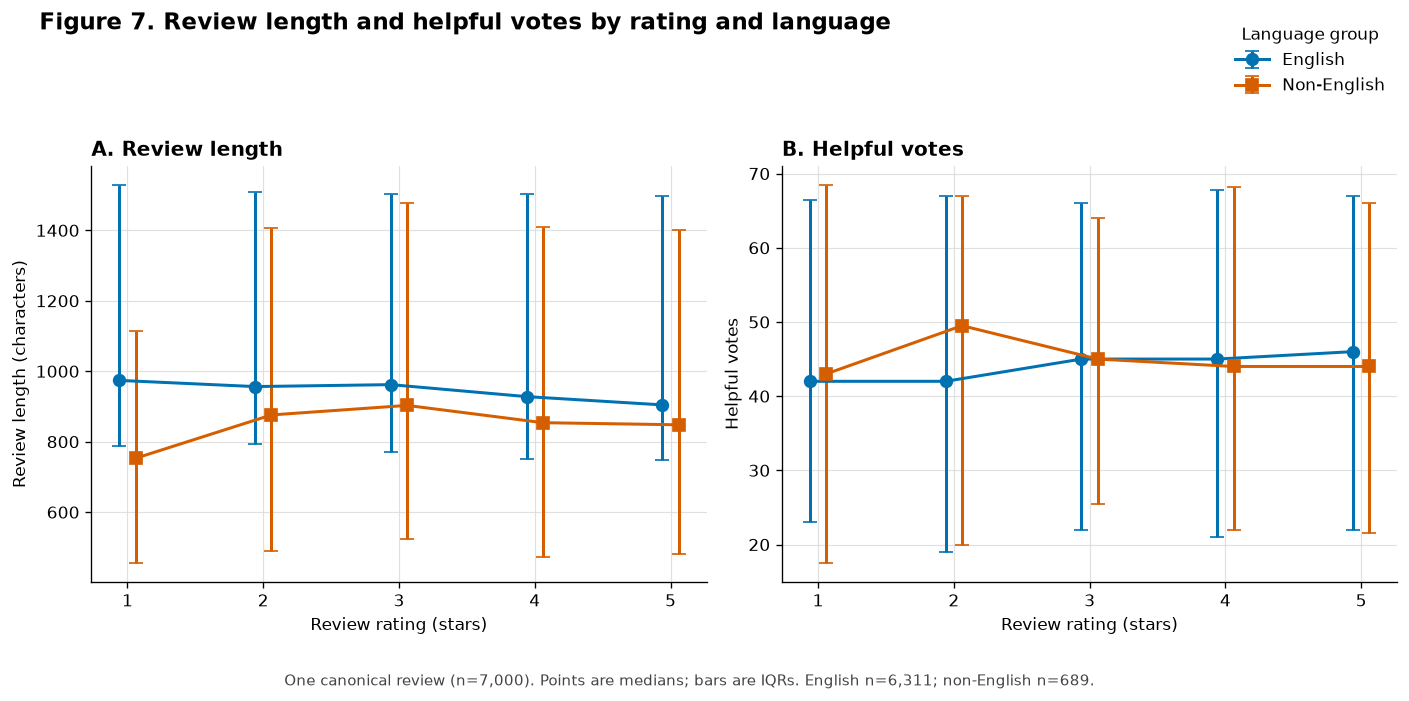

FIGURE7_COMPLETE reviews=7000 groups=10


**Figure 8 category denominators, means and uncertainty**

,category,reviews,mean_rating,rating_sd,standard_error,ci95_low,ci95_high
0,Audio,707,3.291,1.119,0.042,3.209,3.374
1,Networking,699,3.308,1.116,0.042,3.225,3.390
2,Laptop,691,3.326,1.101,0.042,3.244,3.408
3,Gaming,686,3.402,1.053,0.040,3.324,3.481
4,Tablet,705,3.414,1.038,0.039,3.338,3.491
5,Smartphone,696,4.034,1.274,0.048,3.940,4.129
6,Wearable,716,4.094,1.225,0.046,4.004,4.183
7,Smart Home,713,4.136,1.227,0.046,4.046,4.226
8,Home Entertainment,666,4.150,1.207,0.047,4.058,4.242
9,Accessory,721,4.197,1.204,0.045,4.109,4.285


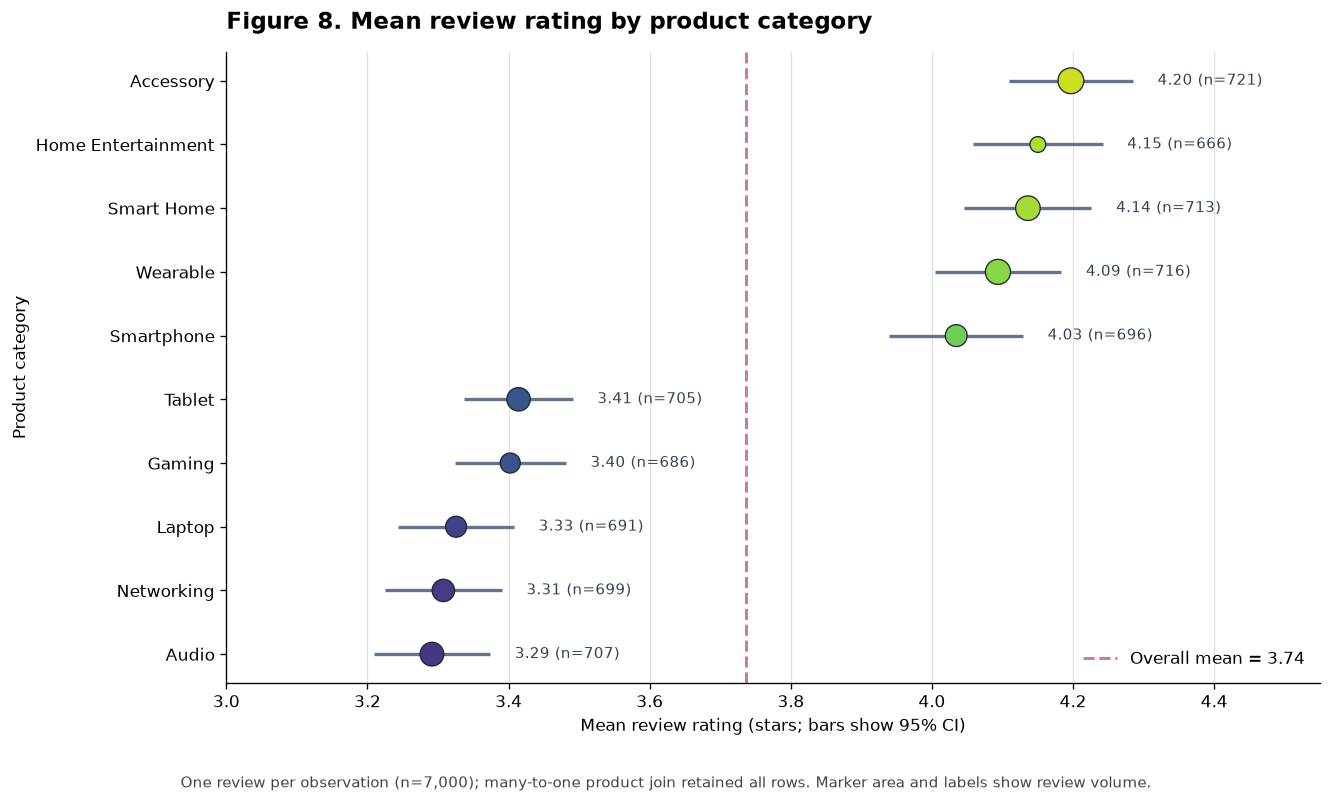

FIGURE8_COMPLETE reviews=7000 categories=10 correlation=0.156


**Task 6 review evidence**

,evidence,observed
0,English/non-English reviews,"6,311 / 689"
1,Lowest/highest category mean,Audio 3.291 / Accessory 4.197
2,Low ratings (1–2 stars),"1,166/7,000 (16.7%)"
3,Reviews per product,median=7; range=1–8


TASK6_REVIEW_EVIDENCE_COMPLETE rows=4 models_trained=0


In [9]:
required_product_columns = {"product_id", "category", "brand", "unit_price"}
required_review_columns = {"review_id", "product_id", "rating", "language_code", "helpful_votes", "review_length_chars"}
if required_product_columns.difference(products.columns) or required_review_columns.difference(product_reviews.columns):
    raise KeyError("products or product_reviews is missing a Figure 7/8 field")

fig78_products = products[list(required_product_columns)].copy()
fig78_reviews = product_reviews.copy()
fig78_products["unit_price"] = pd.to_numeric(fig78_products["unit_price"], errors="raise")
for numeric_column in ["rating", "helpful_votes", "review_length_chars", "review_word_count"]:
    fig78_reviews[numeric_column] = pd.to_numeric(fig78_reviews[numeric_column], errors="raise")
if not fig78_products["product_id"].is_unique:
    raise AssertionError("products.product_id must be unique")
if not fig78_reviews["review_id"].is_unique:
    raise AssertionError("product_reviews.review_id must be unique")

orphan_product_ids = set(fig78_reviews["product_id"]) - set(fig78_products["product_id"])
review_product_analysis = fig78_reviews.merge(
    fig78_products[["product_id", "category", "brand", "unit_price"]],
    on="product_id", how="left", validate="many_to_one", indicator=True,
)
fig78_multiplication_factor = len(review_product_analysis) / review_product_analysis["review_id"].nunique()
fig78_join_check = pd.DataFrame([
    {"check": "products rows / unique product_id", "observed": f"{len(fig78_products):,} / {fig78_products['product_id'].nunique():,}", "expected": "unique"},
    {"check": "reviews rows / unique review_id", "observed": f"{len(fig78_reviews):,} / {fig78_reviews['review_id'].nunique():,}", "expected": "unique"},
    {"check": "orphan review product_id", "observed": len(orphan_product_ids), "expected": 0},
    {"check": "rows after many-to-one join", "observed": len(review_product_analysis), "expected": len(fig78_reviews)},
    {"check": "row multiplication factor", "observed": fig78_multiplication_factor, "expected": 1.0},
])
if orphan_product_ids or not review_product_analysis["_merge"].eq("both").all() or not np.isclose(fig78_multiplication_factor, 1.0):
    raise AssertionError("Figure 8 product join validation failed")
review_product_analysis = review_product_analysis.drop(columns="_merge")
display(Markdown("**Figures 7–8 grain and join checks**"))
display(fig78_join_check)

# Figure 7
review_text_analysis = fig78_reviews.copy()
review_text_analysis["language_group"] = np.where(review_text_analysis["language_code"].eq("en"), "English", "Non-English")
rating_language_summary = (
    review_text_analysis.groupby(["rating", "language_group"], observed=True)
    .agg(
        reviews=("review_id", "size"), median_length=("review_length_chars", "median"),
        q1_length=("review_length_chars", lambda values: values.quantile(0.25)),
        q3_length=("review_length_chars", lambda values: values.quantile(0.75)),
        median_helpful=("helpful_votes", "median"),
        q1_helpful=("helpful_votes", lambda values: values.quantile(0.25)),
        q3_helpful=("helpful_votes", lambda values: values.quantile(0.75)),
    ).reset_index().sort_values(["rating", "language_group"])
)
if int(rating_language_summary["reviews"].sum()) != len(fig78_reviews):
    raise AssertionError("Figure 7 group denominators do not reconcile")
display(Markdown("**Figure 7 group denominators and robust summaries**"))
display(rating_language_summary.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.8), sharex=True)
language_styles = {
    "English": {"color": "#0072B2", "marker": "o", "offset": -0.06},
    "Non-English": {"color": "#D55E00", "marker": "s", "offset": 0.06},
}
for language_group, style in language_styles.items():
    group = rating_language_summary.loc[rating_language_summary["language_group"].eq(language_group)].set_index("rating").reindex([1, 2, 3, 4, 5])
    x_values = np.arange(1, 6) + style["offset"]
    axes[0].errorbar(x_values, group["median_length"], yerr=np.vstack([group["median_length"] - group["q1_length"], group["q3_length"] - group["median_length"]]), color=style["color"], marker=style["marker"], markersize=7, linewidth=1.8, capsize=4, label=language_group)
    axes[1].errorbar(x_values, group["median_helpful"], yerr=np.vstack([group["median_helpful"] - group["q1_helpful"], group["q3_helpful"] - group["median_helpful"]]), color=style["color"], marker=style["marker"], markersize=7, linewidth=1.8, capsize=4, label=language_group)
axes[0].set_title("A. Review length", loc="left", fontweight="bold")
axes[0].set_ylabel("Review length (characters)")
axes[1].set_title("B. Helpful votes", loc="left", fontweight="bold")
axes[1].set_ylabel("Helpful votes")
for axis in axes:
    axis.set_xlabel("Review rating (stars)")
    axis.set_xticks([1, 2, 3, 4, 5])
    axis.grid(color="#D9D9D9", linewidth=0.7, alpha=0.8)
    axis.set_axisbelow(True)
fig.suptitle("Figure 7. Review length and helpful votes by rating and language", x=0.07, ha="left", fontsize=14, fontweight="bold")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", bbox_to_anchor=(0.97, 0.98), frameon=False, title="Language group")
fig.text(0.5, 0.012, "One canonical review (n=7,000). Points are medians; bars are IQRs. English n=6,311; non-English n=689.", ha="center", fontsize=9, color="#444444")
fig.tight_layout(rect=(0.04, 0.06, 0.98, 0.88))
plt.show()
print(f"FIGURE7_COMPLETE reviews={len(fig78_reviews)} groups={len(rating_language_summary)}")

# Figure 8
category_review_summary = (
    review_product_analysis.groupby("category", observed=True)["rating"]
    .agg(reviews="size", mean_rating="mean", rating_sd="std").reset_index()
)
category_review_summary["standard_error"] = category_review_summary["rating_sd"] / np.sqrt(category_review_summary["reviews"])
category_review_summary["ci95_low"] = category_review_summary["mean_rating"] - 1.96 * category_review_summary["standard_error"]
category_review_summary["ci95_high"] = category_review_summary["mean_rating"] + 1.96 * category_review_summary["standard_error"]
category_review_summary = category_review_summary.sort_values("mean_rating", kind="stable").reset_index(drop=True)
overall_mean_rating = review_product_analysis["rating"].mean()
volume_rating_correlation = category_review_summary["reviews"].corr(category_review_summary["mean_rating"])
if int(category_review_summary["reviews"].sum()) != len(review_product_analysis):
    raise AssertionError("Figure 8 category denominators do not reconcile")
display(Markdown("**Figure 8 category denominators, means and uncertainty**"))
display(category_review_summary.round(3))

fig, ax = plt.subplots(figsize=(11.2, 6.7))
y_positions = np.arange(len(category_review_summary))
ax.hlines(y=y_positions, xmin=category_review_summary["ci95_low"], xmax=category_review_summary["ci95_high"], color="#64748B", linewidth=2.0, zorder=1)
minimum_volume = category_review_summary["reviews"].min()
maximum_volume = category_review_summary["reviews"].max()
volume_span = max(maximum_volume - minimum_volume, 1)
marker_sizes = 90 + ((category_review_summary["reviews"] - minimum_volume) / volume_span) * 150
ax.scatter(category_review_summary["mean_rating"], y_positions, s=marker_sizes, c=category_review_summary["mean_rating"], cmap="viridis", vmin=3.1, vmax=4.3, edgecolor="#1F2937", linewidth=0.8, zorder=2)
for y_position, row in category_review_summary.iterrows():
    ax.text(row["ci95_high"] + 0.035, y_position, f"{row['mean_rating']:.2f} (n={int(row['reviews']):,})", va="center", fontsize=9, color="#374151")
ax.axvline(overall_mean_rating, color="#CC79A7", linestyle="--", linewidth=1.8, label=f"Overall mean = {overall_mean_rating:.2f}")
ax.set_yticks(y_positions, category_review_summary["category"])
ax.set_xlim(3.0, 4.55)
ax.set_xlabel("Mean review rating (stars; bars show 95% CI)")
ax.set_ylabel("Product category")
ax.set_title("Figure 8. Mean review rating by product category", loc="left", fontsize=14, fontweight="bold", pad=14)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
fig.text(0.5, 0.012, "One review per observation (n=7,000); many-to-one product join retained all rows. Marker area and labels show review volume.", ha="center", fontsize=9, color="#444444")
fig.tight_layout(rect=(0, 0.055, 1, 1))
plt.show()
print(f"FIGURE8_COMPLETE reviews={len(review_product_analysis)} categories={len(category_review_summary)} correlation={volume_rating_correlation:.3f}")

# Reproducible Task 6 statistics not all shown directly on the two plots.
english_reviews = int(review_text_analysis["language_group"].eq("English").sum())
non_english_reviews = int(review_text_analysis["language_group"].eq("Non-English").sum())
low_rating_count = int(fig78_reviews["rating"].le(2).sum())
low_rating_rate = low_rating_count / len(fig78_reviews)
product_review_counts = fig78_reviews.groupby("product_id").size()
lowest_category = category_review_summary.iloc[0]
highest_category = category_review_summary.iloc[-1]
task6_review_evidence = pd.DataFrame([
    {"evidence": "English/non-English reviews", "observed": f"{english_reviews:,} / {non_english_reviews:,}"},
    {"evidence": "Lowest/highest category mean", "observed": f"{lowest_category['category']} {lowest_category['mean_rating']:.3f} / {highest_category['category']} {highest_category['mean_rating']:.3f}"},
    {"evidence": "Low ratings (1–2 stars)", "observed": f"{low_rating_count:,}/{len(fig78_reviews):,} ({low_rating_rate:.1%})"},
    {"evidence": "Reviews per product", "observed": f"median={product_review_counts.median():.0f}; range={product_review_counts.min()}–{product_review_counts.max()}"},
])
display(Markdown("**Task 6 review evidence**"))
display(task6_review_evidence)
print(f"TASK6_REVIEW_EVIDENCE_COMPLETE rows={len(task6_review_evidence)} models_trained=0")

## 3. Ten evidence-based findings

Write exactly ten numbered findings. Keep each concise and decision-focused.
Each must identify the evidence, grain, magnitude/denominator, business meaning,
an alternative explanation or uncertainty, and a proportionate implication.
One figure may support more than one genuinely distinct finding.


1. **Finding 1:** At the one-order grain, Figure 1 shows a right-skewed distribution across 5,000 completed orders: the median is A$2,491.42 and the IQR is A$1,449.17–A$3,951.42. Percentiles therefore describe a typical transaction better than the extreme tail for retail planning. Product-price heterogeneity may explain much of the spread; examine category-adjusted totals before setting one benchmark.
2. **Finding 2:** Figure 1 places 500/5,000 orders (10%) at or above the A$5,702.77 90th percentile. This high-value segment may warrant targeted service or audit, but premium products and multi-unit baskets are plausible legitimate explanations. Profile product mix and customer history before treating tail membership as anomalous.
3. **Finding 3:** After aggregating 15,711 item rows to 5,000 orders, Figure 2 shows median order total rising from A$551.08 for one unit (n=324) to A$5,245.05 for 8+ units (n=143), with Spearman ρ=0.634. The relationship supports basket-aware planning, but is partly mechanical and confounded by price and mix; analyse category and unit price before bundle decisions.
4. **Finding 4:** At the one-order grain, Figure 3 compares all 5,000 matched orders. Mainstream has the highest median order total (A$2,561.43) and Small Business the lowest (A$2,440.52), a difference of A$120.91 or 5.0%; IQRs overlap substantially. Segment alone offers limited value separation, so test product mix, tenure and frequency before broad segment-specific offers.
5. **Finding 5:** Figure 4 aggregates 5,000 orders into 48 segment/month observations. Revenue peaks differ—Mainstream in October, Premium in July, Small Business in April and Value in November—potentially informing campaign timing. However, totals combine segment size, frequency and order value, and only one year is observed; validate the pattern with additional years or controlled campaigns.
6. **Finding 6:** At the delivery grain, Figure 5 reports 196/5,000 late deliveries (3.92%), so 96.08% were not late. This is a useful service baseline but creates a highly imbalanced prediction target. Because the snapshot covers about one year, it may not represent future operations; monitor the rate over time and use imbalance-sensitive model metrics rather than accuracy alone.
7. **Finding 7:** Figure 5 shows StarTrack with the highest carrier late rate, 4.51% (57/1,263), and DHL the lowest, 3.57% (45/1,262), a 0.95-point spread. This identifies a review priority, not a causal carrier ranking: distance, warehouse, service mix and random variation remain plausible. Compare like-for-like deliveries and quantify uncertainty before reallocating volume.
8. **Finding 8:** Figure 6 uses 5,000 one-to-one order–delivery pairs in five value bands of 1,000. Late rates are non-monotonic, while overall Express and Standard rates are close (3.79% versus 3.95%). Express cells contain only 5–9 late events and operational mix is uncontrolled; test value and service as predictors rather than causal allocation rules.
9. **Finding 9:** At the one-review grain, Figure 7 covers 6,311 English and 689 non-English reviews. English median length falls from 974 characters at 1 star to 904.5 at 5 stars, while helpful-vote medians across rating/language cells stay within 42–49.5. Script differences, unequal group size and review exposure may explain the pattern; compare token-normalised length and exposure-adjusted helpfulness before changing support policy.
10. **Finding 10:** Figure 8 shows mean rating from 3.291 for Audio (n=707) to 4.197 for Accessory (n=721), a 0.906-star gap. Category counts are balanced at 666–721 and correlate weakly with mean rating (r=0.156), so volume alone does not explain the ordering. Reviewer selection and product mix remain plausible; use product-level, time-aware adjusted comparisons before supplier or assortment decisions.

## 4. Five future machine-learning questions

Write exactly five numbered questions covering at least two problem types.
Model training is not required. Keep each response compact enough for the
ten-page report.


### MLQ-1: Which completed orders have anomalous value given their basket composition?

| Element | Response |
|---|---|
| EDA evidence | Figures 1–2 show a right tail and wide within-size variation; 500/5,000 orders are at or above A$5,702.77. |
| Business decision | Prioritise orders for fraud or data-quality review without blocking legitimate premium purchases. |
| Problem type and analysis unit | Unsupervised anomaly detection; one submitted order after aggregating its item rows. |
| Target or unsupervised objective | Produce an anomaly score for order value conditional on basket size and item-price composition. |
| Decision-time predictors | Order total, units, line count, price summaries, discount, delivery charge, tax, channel and submission time. |
| Validation split and metric | Fit earlier orders and assess a later holdout; use precision@k after adjudication and flag-rate stability over time. |
| Leakage, fairness or deployment risk | Labels are initially absent and premium products may be false positives. Exclude post-review fields, monitor drift and require human review with reason codes. |

### MLQ-2: How much will each customer spend next month?

| Element | Response |
|---|---|
| EDA evidence | Figures 3–4 show overlapping order-value distributions but different revenue peaks, suggesting behaviour and timing add information beyond segment labels. |
| Business decision | Estimate future customer value for retention planning and segment-level budgeting. |
| Problem type and analysis unit | Regression; one customer at a month-end snapshot. |
| Target or unsupervised objective | Total `order_total` generated by that customer during the following calendar month. |
| Decision-time predictors | Historical order count, recency, average order value, prior-12-month orders, lifetime value, segment, loyalty tier, preferred channel and recent channel mix, measured at the snapshot. |
| Validation split and metric | Use rolling-origin validation trained only on earlier months; report MAE and RMSE for typical and large errors. |
| Leakage, fairness or deployment risk | Future orders, updated lifetime value and post-cutoff fields cause temporal leakage. Monitor sparse histories, drift and unequal errors across customer segments. |

### MLQ-3: Can late-delivery risk be predicted at dispatch?

| Element | Response |
|---|---|
| EDA evidence | Figures 5–6 show 196/5,000 late deliveries (3.92%); carrier, service and value-band rates vary modestly and non-monotonically. |
| Business decision | At dispatch, prioritise higher-risk deliveries for customer notification or logistics intervention within a fixed alert capacity. |
| Problem type and analysis unit | Binary classification; one dispatched delivery joined one-to-one to its order. |
| Target or unsupervised objective | `is_late`: delivered after the promised date (`delay_days > 0`); final outcome fields label completed deliveries only. |
| Decision-time predictors | Carrier, service/expedited flag, promised window, distance, fulfilment hours, warehouse, order total, item count and dispatch-calendar features. |
| Validation split and metric | Use a chronological 70%/15%/15% split by dispatch date. Report PR-AUC, recall at a fixed alert budget and calibration. |
| Leakage, fairness or deployment risk | Exclude final delivery fields and post-dispatch tracking. Audit errors by carrier, service, warehouse and geography; monitor alert fatigue and temporal drift. |

### MLQ-4: Which delivered order items are at risk of receiving a low review?

| Element | Response |
|---|---|
| EDA evidence | Figures 7–8 report 1,166/7,000 reviews (16.7%) at 1–2 stars, with rating variation by language and product category. |
| Business decision | After delivery but before review submission, prioritise a capacity-limited service-recovery or feedback request. |
| Problem type and analysis unit | Binary classification; one delivered `order_item_id` eligible to receive a review. |
| Target or unsupervised objective | Whether its subsequently submitted canonical review has `rating <= 2`; unreviewed eligible items must be reported separately. |
| Decision-time predictors | Product attributes, item quantity/discount, channel, customer history, carrier, service level and realised delivery delay available by delivery. |
| Validation split and metric | Use rolling-origin validation with the latest period held out; report PR-AUC, recall/precision at outreach capacity and calibration. |
| Leakage, fairness or deployment risk | Exclude review text, rating and helpful votes. Reviewer selection creates bias; monitor subgroup calibration, intervention burden and drift across category, language and region. |

### MLQ-5: Can products be grouped into stable review-behaviour profiles?

| Element | Response |
|---|---|
| EDA evidence | Figures 7–8 show a 0.906-star category gap; product histories are sparse (median 7 reviews, range 1–8). |
| Business decision | Create product groups for quality investigation, supplier review or follow-up beyond published categories. |
| Problem type and analysis unit | Unsupervised clustering; one `product_id` represented at an analysis snapshot. |
| Target or unsupervised objective | Find stable, interpretable groups from product attributes and aggregated historical review behaviour; there is no supervised target. |
| Decision-time predictors | Rating level/variability, length, helpfulness, low-rating/language shares, review count, price, warranty and category available at the snapshot. |
| Validation split and metric | Build on earlier reviews and test stability on later reviews and bootstraps; report silhouette score and adjusted Rand/Jaccard stability. |
| Leakage, fairness or deployment risk | Sparse histories and scaling can dominate clusters; script/language can proxy demographics. Treat groups as descriptive and require human review before labelling. |

## 5. Limitations and conclusion

Summarise the most decision-relevant limitations, what the data cannot establish
and the next evidence needed. End with a concise conclusion rather than new
analysis.


Replace with limitations and conclusion.


## References

Use one consistent referencing style for external facts, code, data and ideas.
